# 基本モジュール

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# @title モジュールのインストール
# !pip install -qq datasets==3.2.0
# !pip install -qq mecab-python3==1.0.8
# !pip install -qq unidic-lite
# !git clone https://github.com/Michi-123/whiteGPT.git

In [ ]:
# @title モジュールの読み込み
import os
import math
import copy
import random
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD, Adam, AdamW # 最適化モジュール
from matplotlib import pyplot as plt # グラフの描画


In [ ]:
# その他のライブラリー
# import MeCab # 形態素解析
# import datasets # 青空文庫用

In [ ]:
%cd /content/drive/MyDrive/DeepSeek/code

from deepseekcode_0_5_7 import DeepSeekCode, create_causal_mask, pad_mask_after_eos
from tokenizer_0_2_3 import Tokenizer
from deepseekdataset_0_3_0 import DeepSeekDataset, DataLoader , ArithmeticDataset # 算数用のデータセット
from checkpoint_0_1_0 import save_checkpoint, load_checkpoint

In [ ]:
# デバイス設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

# モデルのハイパーパラメータ

In [ ]:
# @title メインパラメータ

# V2 paper
# d_model: 5120
# n_layers: 60
# context_size: 128K

# V3 paper
# d_model: 5120 + 2048 = 7168

#@markdown 埋め込み次元
d_model = 128 #@param{type:"integer"}

#@markdown Transformer レイヤーの数
n_layers = 6 #@param{type:"integer"}

#@markdown 最大文字数
context_size = 30 #@param{type:"integer"}

#@markdown ゼロ除算防止の補正値 （$e$）
norm_eps = 1e-8 # @param{type:'number'}

In [ ]:


#@title  MLAパラメータ

# V2 paper
# n_heads: 128
# d_head: 128
# d_c: 512
# d_cQ: 1536
# d_rope: 64


#@markdown MLA
n_heads = 8 #@param{type:"integer"}
d_head = 16  #@param{type:"integer"}
d_c    = 32 #@param{type:"integer"}
d_cQ   = 64 #@param{type:"integer"}
# d_cQ > d_c
d_rope = 8 #@param{type:"integer"}

#@markdown RoPE
max_seq_len = 1000 #@param{type:"integer"}
rope_theta = 10000 #@param{type:"number"}

In [ ]:
#@title MoE パラメータ

# DeepSeekMoE paper
# n_shared_experts: 2
# n_routed_experts: 62
# n_activated_experts: 6

n_shared_experts = 1 #@param{type:"integer"}

# 4演算子に対応
n_routed_experts = 8 #@param{type:"integer"}

n_activated_experts = 2 #@param{type:"integer"}

# bias update speed 𝛾 to 0.001 for the first 14.3T tokens, and to 0.0 for the remaining 500B tokens. F
moe_bias_update_speed = 0.001 #@param{type:"number"}

# moe_alpha: 0.0001
# moe_alpha = 0.0001 #@param{type:"number"}

# moe_inter_dim: d_model * 4
moe_inter_dim = 64 #@param{type:"integer"}


aux_loss_alpha = 0.0001 #@param{type:"number"}

In [ ]:
# @title  Multi-Token Prediction

# 論文
multi_token_depth = 1 #@param{type:"integer"}

#
lambda_mtp = 0.1 #@param{type:"number"}

In [ ]:
# @title ModelArgs
class Args:
    def __init__(self, **kwargs):
        for key, value in kwargs.items():
            setattr(self, key, value)

# 算数の事前学習

In [ ]:
tokenizer_path = '/content/drive/MyDrive/DeepSeek/model/arithmetic_tokenizer.pkl' #@param {type: "string"}
base_checkpoint_path = '/content/drive/MyDrive/DeepSeek/model/arithmetic_base_checkpoint_0.7.1.pt'  # @param{type:"string"}

各プロンプトは「推論過程（…）」と「最終回答（…）」の2段構成を明示的に求める形式です。 内容や分野にバイアスをかけず、構造のみを指定しています。

このテンプレートは、

ユーザー: <質問文>

アシスタント: 推論過程最終回答 という構造のみを指定し、内容や推論方法には制約を設けていません。 この形式を用いることで、モデルは推論過程と最終回答を明確に分離して出力するよう学習します。

In [ ]:
args = Args(
        d_model=d_model,
        vocab_size=None,
        n_heads=n_heads,
        n_layers=n_layers,
        context_size=context_size,
        norm_eps=norm_eps,
        d_c=d_c,
        d_cQ=d_cQ,
        d_rope=d_rope,
        d_head=d_head,
        max_seq_len=max_seq_len,
        rope_theta=rope_theta,
        n_shared_experts=n_shared_experts,
        n_routed_experts=n_routed_experts,
        n_activated_experts=n_activated_experts,
        moe_inter_dim=moe_inter_dim,
        moe_bias_update_speed=moe_bias_update_speed,
        aux_loss_alpha=aux_loss_alpha,
        multi_token_depth=multi_token_depth,
        lambda_mtp=lambda_mtp,
        score_func='Sigmoid',
        )

In [ ]:
# @title 学習ハイパーパラメータ

# DeepSeek論文準拠: 2.2*10e-4
learning_rate = 1e-3 #@param{type:'number'}

epochs = 200 #@param{type:'integer'}
batch_size = 64 #@param{type:'integer'}
grad_clip_norm = 1.0 #@param{type:'number'}
# 初期値の偏りが大きいので、学習推移を確認しやすい
seed = 42 #@param{type:'integer'}

割り算が無い場合はepoch数は20で良い

In [ ]:
# @title 算数用のコーパス（語彙のみ）
corpus = ' 1 2 3 4 5 6 7 8 9 0 '
corpus += ' + - * / = '
corpus += ' たす ひく かける かけ わる 足す 引く 掛ける 掛け 割る '
corpus += ' ＋ ー × ÷ ＝ は ？ x ? '

In [ ]:
# 事前学習コンテキストサイズ（事前学習用にモデルの入力サイズに、次の単語 + Multi-Token Predictionの深度を追加）
base_context_size = args.context_size + 1 + args.multi_token_depth
base_context_size

In [ ]:
tokenizer = Tokenizer(corpus)
args.vocab_size = tokenizer.vocab_size
args.vocab_size

In [ ]:
#@title test関数
def test(model, prompt=None):

    if prompt is None:
        # prompt = '52ひく53は?'
        suffled_data = random.sample(test_data, len(test_data))
        prompt = suffled_data[0]

    print(prompt)
    prompt = tokenizer.parse(prompt)
    input_ids = tokenizer.encode(prompt).to(device)
    model.eval()
    with torch.no_grad():
        # Ensure KV cache is reset before generation
        model.reset_kv_cache()
        model.generate_text(input_ids, tokenizer, max_new_tokens=50, temperature=1.0, top_k=1, eos_token_id=2, max_cache_size=None, delay=0.0)
    print()

In [ ]:
# @title モデルのインスタンス化
torch.manual_seed(seed)
random.seed(seed)

tokenizer = Tokenizer(corpus)
args.vocab_size = tokenizer.vocab_size
base_model = DeepSeekCode(args, device)
# base_optimizer = Adam(base_model.parameters(), lr=learning_rate) #モメンタム法＋ルート平均二乗伝播法＋バイアス補正
base_optimizer = AdamW(base_model.parameters(), # 重み減衰付きAdam
                       lr=learning_rate,   #2.2e-4
                       betas=(0.9, 0.95),
                       weight_decay=0.1,  # L2正則化
                       eps=1e-8  # 0 除算回避のための定数
                       )


In [ ]:
if __name__ == '__main__':
    test(base_model, "-23+43=")
    print('Answer: ',-23+43)

In [ ]:
# Load base-model
is_load_base_model = True #@param{type:'boolean'}
if is_load_base_model:
    start_epoch, losses =  load_checkpoint(args, base_model, base_checkpoint_path, base_optimizer)
else:
    start_epoch = 0
    losses = []

In [ ]:
if __name__ == '__main__':
    test(base_model, "-23+43=")
    print('Answer: ',-23+43)

In [ ]:
# from deepseekcode_0_5_6 import MoE


In [ ]:
# @title 算数の学習 V3 Train
# moe_inference = False
from tqdm import tqdm

# Epoch数まで繰り
for epoch in range(start_epoch, epochs):
    print('epoch', epoch)

    # 損失の累計をリセット
    running_loss = 0.0

    # 学習モードに変更
    base_model.train()
    base_model.to(device)

    # 事前学習用データセット
    train_dataset = ArithmeticDataset(tokenizer, base_context_size, dataset_size=batch_size*100, use_division=False)
    # train_dataset = ArithmeticDataset(tokenizer, args.context_size, dataset_size=batch_size*100, use_division=False)
    # Mecabの機能を追加
    # train_dataset.tagger = tagger

    # データローダーの作成（自動でミニバッチを作成）
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=False)
    data_iter = iter(test_dataloader)

    # 学習データセット全体をバッチ単位で処理
    for i, input_ids in enumerate(tqdm(train_dataloader)):

        # 勾配のリセット
        base_optimizer.zero_grad()

        loss = base_model.pretrain(input_ids.to(device))
        # 損失計算
        # なし (メインモデルで計算済み)

        # 誤差逆伝播
        loss.backward()

        # 勾配クリッピング
        torch.nn.utils.clip_grad_norm_(base_model.parameters(), grad_clip_norm)

        # 学習パラメータの更新
        base_optimizer.step()

        # 損失の累積
        running_loss += loss.item()

        # Expert biasの更新
        # 1. Main model
        for block in base_model.main_model.layers:
            if hasattr(block, 'feed_forward') and  \
            block.feed_forward.__class__.__name__ == 'MoE':
                block.feed_forward.update_expert_bias()
        # 2. MTP moules
        for mtp_module in base_model.mtp_modules:
            if hasattr(mtp_module.transformer_block, 'feed_forward') and \
            mtp_module.transformer_block.feed_forward.__class__.__name__ == 'MoE':
                mtp_module.transformer_block.feed_forward.update_expert_bias()

    # 現在の学習率を表示
    # print(f"Epoch {epoch}: lr = {base_optimizer.param_groups[0]['lr']}")

    # 損失の履歴を作成
    train_loss = running_loss / len(train_dataloader)
    losses.append(train_loss)

    # 開始epochの更新
    start_epoch = epoch

    # Validate
    if epoch % 1 == 0: # 10
        prompt = '1+2'
        test_ids = tokenizer.encode(prompt)
        test_ids = test_ids.unsqueeze(0).to(device)
        causal_mask = create_causal_mask(test_ids.size(1)).to(device)
        generated_ids = base_model.generate_ids(test_ids, max_new_tokens=20, top_k=1, causal_mask=causal_mask)

        generated_text = tokenizer.decode(generated_ids)
        print('>', prompt)
        print('<', generated_text)

    # 損失の確認
    if epoch % 1 == 0: # 10
        lr = base_optimizer.param_groups[0]['lr']
        print(f"epoch:{epoch}  lr:{lr:.7f} loss:{train_loss:.6f}")

    # モデルの保存
    if epoch % 1 == 0 and epoch != 0: # 10
        try:
            save_checkpoint(args, base_model, base_optimizer, epoch, losses, base_checkpoint_path)
            print("Saved")
        except:
            print("Save error")
            raise

    # グラフの描画
    if epoch % 1== 0 and epoch != 0: # 20
        if epoch < 10:
            plt.plot(losses)
        else:
            plt.plot(losses[10:])
        plt.show()

In [ ]:
test_dataset = ArithmeticDataset(tokenizer, base_context_size, dataset_size=batch_size*1, use_division=False)
input_data = tokenizer.decode(test_dataset[0])
predinted = test(base_model, input_data)

In [ ]:
if __name__ == '__main__':
    test(base_model, "-23+43=")
    print('Answer: ',-23+43)

In [ ]:
# 数値で検証
test(base_model, "-23+72=")
print('=', -23+72)
test(base_model, "23-72=")
print('=', 23-72)
test(base_model, "10-82=")



In [ ]:
# 言葉で検証
test(base_model, "23ひく43は?")

# 追加学習用のクラス

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
import re
from typing import List, Dict

In [ ]:
# @title LoRALayer
# https://chat.deepseek.com/a/chat/s/a6eab189-088a-40d8-beae-8c9039bef22f

class LoRALayer(nn.Module):
    def __init__(self, original_layer: nn.Linear, rank: int = 2, alpha: float = 4.0):
        super().__init__()
        self.original_layer = original_layer
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank
        # self.scaling = rank ** -0.5

        # 元の層のパラメータを固定
        for param in original_layer.parameters():
            param.requires_grad = False

        # LoRAのための低ランク行列を初期化
        in_features = original_layer.in_features
        out_features = original_layer.out_features

        self.lora_A = nn.Parameter(torch.zeros(rank, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))

        # 初期化
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        original_output = self.original_layer(x)
        lora_output = (x @ self.lora_A.T @ self.lora_B.T) * self.scaling
        return original_output + lora_output

In [ ]:
# @title DeepSeekLoRA
# https://chat.deepseek.com/a/chat/s/a6eab189-088a-40d8-beae-8c9039bef22f

class DeepSeekLoRA(nn.Module):
    def __init__(self, base_model, lora_rank=2, lora_alpha=0.5):
        super().__init__()

        self.args = base_model.args
        self.device = base_model.device
        self.vocab_size = base_model.vocab_size
        self.context_size = base_model.context_size

        # self.base_model = base_model
        self.main_model = base_model.main_model
        self.mtp_modules = base_model.mtp_modules

        self.embedding = base_model.embedding
        self.output_head = base_model.output_head
        self.freqs_cis = base_model.freqs_cis.to(device)

        self.lora_rank = lora_rank
        self.lora_alpha = lora_alpha

        # LoRAを適用する層を置換
        self._apply_lora_to_attention()
        self._apply_lora_to_ffn()
        self._apply_lora_to_mtp()

        # その他の関数
        self.generate_text = base_model.generate_text
        self.generate_ids = base_model.generate_ids
        self.generate = base_model.generate
        self.compute_log_prob = base_model.compute_log_prob
        self._calculate_main_loss = base_model._calculate_main_loss
        self._calculate_mtp_loss = base_model._calculate_mtp_loss
        self.finetune = base_model.pretrain
        self.reset_kv_cache = base_model.reset_kv_cache

    def _apply_lora_to_attention(self):
        """
        MLA（Multi-Head Latent Attention）のQKVプロジェクションにLoRAを適用
        7個のパラメータに適用
        """
        for layer in self.main_model.layers:

            # AttentionのQKVプロジェクション
            layer.attention.q_down_proj = LoRALayer(layer.attention.q_down_proj, self.lora_rank, self.lora_alpha)
            layer.attention.kr_proj = LoRALayer(layer.attention.kr_proj, self.lora_rank, self.lora_alpha)
            layer.attention.kv_down_proj = LoRALayer(layer.attention.kv_down_proj, self.lora_rank, self.lora_alpha)

            # アッププロジェクション
            layer.attention.qc_up_proj = LoRALayer(layer.attention.qc_up_proj, self.lora_rank, self.lora_alpha)
            layer.attention.qr_up_proj = LoRALayer(layer.attention.qr_up_proj, self.lora_rank, self.lora_alpha)
            layer.attention.kc_up_proj = LoRALayer(layer.attention.kc_up_proj, self.lora_rank, self.lora_alpha)
            layer.attention.vc_up_proj = LoRALayer(layer.attention.vc_up_proj, self.lora_rank, self.lora_alpha)

    def _apply_lora_to_ffn(self):
        """MoEのExpert（FFN層）にLoRAを適用"""
        for layer in self.main_model.layers:
            layername = layer.feed_forward.__class__.__name__

            if layername == "FeedForward":continue

            for expert in layer.feed_forward.shared_experts:
                expert.w1 = LoRALayer(expert.w1, self.lora_rank, self.lora_alpha)
                expert.w2 = LoRALayer(expert.w2, self.lora_rank, self.lora_alpha)
                expert.w3 = LoRALayer(expert.w3, self.lora_rank, self.lora_alpha)

            for expert in layer.feed_forward.routed_experts:
                expert.w1 = LoRALayer(expert.w1, self.lora_rank, self.lora_alpha)
                expert.w2 = LoRALayer(expert.w2, self.lora_rank, self.lora_alpha)
                expert.w3 = LoRALayer(expert.w3, self.lora_rank, self.lora_alpha)


    def _apply_lora_to_mtp(self):
        """MTPモジュールの線形層にLoRAを適用"""
        for mtp_module in self.mtp_modules:
            mtp_module.projection = LoRALayer(mtp_module.projection, self.lora_rank, self.lora_alpha)

            # MTP内のTransformerブロックにもLoRAを適用
            mtp_module.transformer_block.attention.q_down_proj = LoRALayer(
                mtp_module.transformer_block.attention.q_down_proj, self.lora_rank, self.lora_alpha)
            mtp_module.transformer_block.attention.kr_proj = LoRALayer(
                mtp_module.transformer_block.attention.kr_proj, self.lora_rank, self.lora_alpha)
            mtp_module.transformer_block.attention.kv_down_proj = LoRALayer(
                mtp_module.transformer_block.attention.kv_down_proj, self.lora_rank, self.lora_alpha)

            layername = mtp_module.transformer_block.feed_forward.__class__.__name__
            if layername == "FeedForward":continue

            # FFN層
            for expert in mtp_module.transformer_block.feed_forward.shared_experts:

                expert.w1 = LoRALayer(expert.w1, self.lora_rank, self.lora_alpha)
                expert.w2 = LoRALayer(expert.w2, self.lora_rank, self.lora_alpha)
                expert.w3 = LoRALayer(expert.w3, self.lora_rank, self.lora_alpha)

            for expert in mtp_module.transformer_block.feed_forward.routed_experts:
                expert.w1 = LoRALayer(expert.w1, self.lora_rank, self.lora_alpha)
                expert.w2 = LoRALayer(expert.w2, self.lora_rank, self.lora_alpha)
                expert.w3 = LoRALayer(expert.w3, self.lora_rank, self.lora_alpha)

    def finetune(self, *args, **kwargs):
        """元のモデルのfinetuneをそのまま使用"""
        return self.pretrain(*args, **kwargs)

    def __parameters(self, recurse: bool = True):
        """LoRAパラメータのみを返す"""
        params = []
        for name, module in self.named_modules():
            if isinstance(module, LoRALayer):
                params.extend([p for p in module.parameters() if p.requires_grad])
        return params

    def parameters(self, recurse: bool = True):
        """LoRAパラメータとembedding/output_headのパラメータを返す"""
        params = []

        # LoRAパラメータを収集
        for name, module in self.named_modules():
            if isinstance(module, LoRALayer):
                params.extend([p for p in module.parameters() if p.requires_grad])

        # 埋め込み層のパラメータを追加
        if hasattr(self.main_model, 'embedding'):
            params.append(self.main_model.embedding.weight)

        # 出力ヘッドのパラメータを追加
        if hasattr(self.main_model, 'output_head'):
            params.append(self.main_model.output_head.weight)

        return params

In [ ]:
# @title DeepSeekFullModel
# https://chat.deepseek.com/a/chat/s/a6eab189-088a-40d8-beae-8c9039bef22f

class DeepSeekFullModel(nn.Module):
    def __init__(self, base_model):
        super().__init__()

        self.args = base_model.args
        self.device = base_model.device
        self.vocab_size = base_model.vocab_size
        self.context_size = base_model.context_size

        # self.base_model = base_model
        self.main_model = base_model.main_model
        self.mtp_modules = base_model.mtp_modules

        self.embedding = base_model.embedding
        self.output_head = base_model.output_head
        self.freqs_cis = base_model.freqs_cis.to(device)



        # その他の関数
        self.generate_text = base_model.generate_text
        self.generate_ids = base_model.generate_ids
        self.generate = base_model.generate
        self.compute_log_prob = base_model.compute_log_prob
        self._calculate_main_loss = base_model._calculate_main_loss
        self._calculate_mtp_loss = base_model._calculate_mtp_loss
        self.finetune = base_model.pretrain
        self.reset_kv_cache = base_model.reset_kv_cache

    def finetune(self, *args, **kwargs):
        """元のモデルのfinetuneをそのまま使用"""
        return self.pretrain(*args, **kwargs)

# 教師ありファインチューニング (SFT)

* 最低限のフォーマットの学習
* 報酬ハッキングの防止

In [ ]:
# 教師データで事前学習するためにパディングマスクを適用する方法（推論モデル用）
ids = tokenizer.encode('1+2')
pad = torch.LongTensor([0] * 10)
ids = torch.cat([ids, pad])
ids

In [ ]:
# @title run_supervised_finetuning
def run_supervised_finetuning(batch, model, optimizer):

    context_size = model.context_size
    pads = torch.LongTensor([0] * (context_size))

    input_ids = []
    target_ids = []
    for line in batch:
        ids = tokenizer.encode(line)

        ids = torch.cat([ids, pads])
        ids = ids[:context_size]
        input_ids.append(ids[:-1])
        target_ids.append(ids[1:])

    input_ids = torch.stack(input_ids).to(device)
    target_ids = torch.stack(target_ids).to(device)
    freqs_cis = model.freqs_cis.to(input_ids.device)

    loss = supervised_finetune_step(model, input_ids, target_ids, freqs_cis, args, optimizer)
    return loss

In [ ]:
# @title supervised_finetune_step
def supervised_finetune_step(model, input_ids, target_ids, freqs_cis, args, optimizer):
    model.reset_kv_cache()
    seq_len = input_ids.size(1)
    local_freqs_cis = freqs_cis[:seq_len]
    causal_mask = create_causal_mask(seq_len).to(input_ids.device)

    loss = model.finetune(input_ids, 0, local_freqs_cis, causal_mask, train=True)
    return loss.mean()

In [ ]:
# @title run_inference 推論専用関数
def run_inference(model, prompt, args=None):
    model.to(device)

    main_model = model.main_model


    context_size = main_model.context_size

    # print("--- 推論開始 ---")
    print("プロンプト:", prompt)

    input_ids = tokenizer.encode(prompt)
    input_ids = input_ids[:context_size//2].unsqueeze(0)
    eos_token_id = tokenizer.eos_token_id # integer
    input_ids = input_ids.to(device)

    model.generate_text(input_ids, tokenizer, max_new_tokens=20, top_k=1, eos_token_id=eos_token_id)

In [ ]:
# @title create_arithmetic_samples
def create_arithmetic_samples(tokenizer, sample_size=1):
    dataset = []
    while len(dataset) < sample_size:
        op = random.choice(operations)

        # 値の範囲は -99 〜 99（0も含む）
        x = random.randint(-99, 99)
        y = random.randint(-99, 99)

        # ゼロ除算防止
        if op["symbol"] == "/" and (y == 0 or x % y != 0):
            continue

        try:
            result = op["func"](x, y)
            if result is None:
                continue
        except:
            continue

        # 結果も2桁以内に収める（-99〜99）
        if not (-99 <= result <= 99):
            continue

        question = f"{x}{op['label']}{y}は?"
        think = f"<think>{x} {op['symbol']} {y} = {result}</think>"
        answer = f"<answer>{result}</answer>"

        sequence = f"{question} {think} {answer}<EOS>"
        sequence = tokenizer.parse(sequence)
        dataset.append(sequence)

    return dataset

In [ ]:
# 初期状態の確認
def __test2():
    samples = random.sample(test_data , k=2)
    print(samples[0])
    input_ids = tokenizer.encode(samples[0])
    SFT_model.generate_text(input_ids.to(device), tokenizer)
    print(samples[1])
    input_ids = tokenizer.encode(samples[1])
    SFT_model.generate_text(input_ids.to(device), tokenizer)

In [ ]:
# @title 各演算の定義（日本語表記、全角記号、lambda関数）
operations = [
    {"label": "たす", "symbol": "+", "func": lambda x, y: x + y},
    {"label": "ひく", "symbol": "-", "func": lambda x, y: x - y},
    {"label": "かける", "symbol": "*", "func": lambda x, y: x * y},
    {"label": "わる", "symbol": "/", "func": lambda x, y: x // y if y != 0 and x % y == 0 else None},
    {"label": "足す", "symbol": "+", "func": lambda x, y: x + y},
    {"label": "引く", "symbol": "-", "func": lambda x, y: x - y},
    {"label": "掛ける", "symbol": "*", "func": lambda x, y: x * y},
    {"label": "割る", "symbol": "/", "func": lambda x, y: x // y if y != 0 and x % y == 0 else None},
    {"label": "＋", "symbol": "+", "func": lambda x, y: x + y},
    {"label": "ー", "symbol": "-", "func": lambda x, y: x - y},
    {"label": "×", "symbol": "*", "func": lambda x, y: x * y},
    {"label": "÷", "symbol": "/", "func": lambda x, y: x // y if y != 0 and x % y == 0 else None},
]

In [ ]:
supervised_data_limited = [
    "49＋32は<think> 49+32=81</think><answer>81</answer><EOS>",
    "3 たす 5は<think> 3 + 5 = 8</think><answer>8</answer><eos>",
    "-21たす-34は<think>-21+-34=-55</think><answer>-55</answer><EOS>",
    "58足す13は？<think>-21+(-34)= 71</think><answer>71</answer><EOS>",

    "9 × 6は?<think>9x6=54</think><answer>54</answer><EOS>",
    "9 かける 6は?<think>9x6=54</think><answer>54</answer><EOS>",
    "24 掛ける 3は?<think>24x3=72</think><answer>72</answer><EOS>",

    "37 ー 41は?<think>37-41=-4</think><answer>-4</answer><EOS>",
    "99 ひく 41は?<think>99-41=58</think><answer>58</answer><EOS>",
    "12 引く 35は?<think>12-35=-23</think><answer>-23</answer><EOS>",

    "99 ÷ 3は?\<think>99/3=33</think><answer>33</answer><eos>",
    "50 わる 5は<think>50/5=10</think><answer>10</answer><eos>",
    "34 割る 2は?<think>34/2=17</think><answer>17</answer><eos>",
]

In [ ]:
test_data = [
    "1+3=",
    "9+5=",
    "54+32=",
    "10+22=",
    "-10+22=",
    "-1+-56=",
    "90-45=",
    "21-30=",
    "21*3=",
    "5*4=",
    "-40*2=",
    "-12/3=",
    "55/5=",

    "10たす1は",
    "-78足す32は",
    "71ひく25は",
    "-42引く32は",
    "32×-2は?",
    "28÷14は",
    "10わる1は?",
    "24÷3は?",

    "80-30は?",
    "10 たす 15は？",
    "21たす34は",
    "80足す13は？",

    "3 × 12は?",
    "2 かける 6は?",
    "3 掛ける 21は?",

    "90 ー 41は?",
    "59 ひく 90は?",
    "22 引く 35は?",

    "99 ÷ 11は",
    "20 わる 2は？",
    "10 割る 10は",
]

In [ ]:
# @title 任意の計算で確認
prompt = '-2*6='
test(base_model, prompt)

In [ ]:
learning_rate == 1e-3

In [ ]:
SFT_checkpoint_path = "/content/drive/MyDrive/DeepSeek/model/SFT_checkpoint_0.7.1.pt" # @param{"type":"string"}

In [ ]:
#@title ハイパーパラメータ
learning_rate = 1e-4 #
batc_size = 128
seed = 42

# LoRA設定
lora_rank = 8
lora_alpha = 16.0
# 収束しない
# lora_rank=2
# lora_alpha=0.5

# epochs = 300 # LoRA: 300で収束
epochs = 400 # RL

sample_size = 512 #


In [ ]:
# @title 推論モデル用の教師データの作成
torch.manual_seed(seed)
random.seed(seed)

arithmetic_samples = create_arithmetic_samples(tokenizer, sample_size)

context_size = args.context_size
pads = torch.LongTensor([0] * (context_size))

train_dataset = []
for samples in arithmetic_samples:
    token_ids = tokenizer.encode(samples)
    token_ids = torch.cat([token_ids, pads])
    token_ids = token_ids[:context_size + 1 + args.multi_token_depth]
    train_dataset.append(token_ids)

inference_data = torch.stack(train_dataset)

In [ ]:
# test
print(arithmetic_samples[0])
inference_data.shape

In [ ]:
# @title ベースモデルのインスタンス化
base_model = DeepSeekCode(args, device)
_ = load_checkpoint(args, base_model, base_checkpoint_path)
# パラメータの固定
# for param in base_model.parameters():
#     param.requires_grad = False


In [ ]:
# test
base_model.device


In [ ]:
# test
base_model.freqs_cis.device

In [ ]:
# @title 強化学習用のラッパーモデルインスタンス化

# SFT_model = DeepSeekRL(args, base_model).to(device)
# SFT_model = DeepSeekLoRA(base_model,lora_rank=lora_rank, lora_alpha=lora_alpha).to(device)
SFT_model = DeepSeekFullModel(base_model).to(device)

SFT_optimizer = AdamW(SFT_model.parameters(), # 重み減衰付きAdam
                       lr=learning_rate,
                       betas=(0.9, 0.95),
                       weight_decay=0.1, # L2正則化
                       eps=1e-8 # 0 除算回避のための定数
)

In [ ]:
#LoRA layerの確認2
for name, param in SFT_model.named_parameters():
    if 'lora' in name:
        print(f"{name}: requires_grad={param.requires_grad}")

In [ ]:
# 算数コーパス ★この処理はきれいではないので、データセットクラスを作ってまとめることにする。
# dataset_size = 1000
# dataset_size = 128　だめ
# arithmetic_batch_size = 128　だめ
dataset_size = sample_size
arithmetic_batch_size = sample_size # 1000
arithmetic_dataset = ArithmeticDataset(tokenizer, context_size=context_size + 1 + args.multi_token_depth, dataset_size=dataset_size)
arithmetic_dataloader = DataLoader(arithmetic_dataset, batch_size=arithmetic_batch_size, shuffle=True)

# イテレータを取得
data_iter = iter(arithmetic_dataloader)

# 次のバッチを取得
arithmetic_data = next(data_iter)

In [ ]:
# test
arithmetic_data.shape

In [ ]:
# 教師データ（推論モデル用＋算数用）
sft_train_data = torch.concat((inference_data, arithmetic_data), dim=0)

In [ ]:
# test
print('inference_data', inference_data.shape)
print('arithmetic_data', arithmetic_data.shape)
print('sft_train_data', sft_train_data.shape)

In [ ]:
# test
print(sft_train_data)

In [ ]:
# test
print(tokenizer.decode(inference_data[0], use_eos=True))
print(tokenizer.decode(arithmetic_data[0]))

In [ ]:
# DatasetとDataLoaderの生成
from torch.utils.data import TensorDataset, DataLoader
sft_train_dataset = TensorDataset(sft_train_data)
sft_train_loader = DataLoader(sft_train_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
SFT_model.freqs_cis = SFT_model.freqs_cis.to(device) # 組み込む

In [ ]:
# debug
epochs

In [ ]:
# test
test(base_model, "23ひく43は?")

In [ ]:
# test
test(SFT_model, "23ひく43は?")

In [ ]:
is_load_SFT_model = True #@param{type:'boolean'}
if is_load_SFT_model:

    start_epoch, losses =  load_checkpoint(args, SFT_model, SFT_checkpoint_path, SFT_optimizer)

else:
    start_epoch = 0
    losses = []

In [ ]:
# test
test(SFT_model, "23ひく43は?")
test(SFT_model, "23かける3は?")

In [ ]:
# debug
start_epoch

In [ ]:
#@title SFT train_step
for epoch in range(start_epoch , epochs):

    if is_load_SFT_model:
        break

    SFT_model.to(device)
    SFT_model.train()

    running_loss = 0

    num_iterations = len(sft_train_loader)

    for i, batch in enumerate(sft_train_loader):

        # 勾配初期化
        SFT_optimizer.zero_grad()

        # 入力トークン
        input_ids = batch[0].to(device)

        # Next word prediction を実行し損失計算
        loss = SFT_model.finetune(input_ids)

        # 更新処理
        loss.backward()
        SFT_optimizer.step()

        running_loss += loss.item()

    loss = running_loss / num_iterations
    losses.append(loss)

    if epoch % 1 == 0:
        print(f"Epoch {epoch + 1}/{epochs}   Loss: {loss}")

    try:
        if epoch % 1 == 0:
            save_checkpoint(args, SFT_model, SFT_optimizer, epoch, losses, SFT_checkpoint_path)
            print("Saved")
    except:
        print("Failed to save")


    # グラフの描画
    if epoch % 10== 0 and epoch != 0: # 20
        plt.plot(losses[10:])
        plt.show()

    if epoch % 5 == 0:
        test_index = random.randint(0, 100)

        full_prompt = tokenizer.decode(arithmetic_data[test_index])
        prompt = full_prompt.split('=')[0] + '='
        test(SFT_model, prompt)

        full_prompt = tokenizer.decode(inference_data[test_index])
        prompt = full_prompt.split('<think>')[0]
        test(SFT_model, prompt)

    start_epoch = epoch

In [ ]:
plt.plot(losses[10:])
plt.show()

In [ ]:
# test
test_index = random.randint(0, 100)
full_prompt = tokenizer.decode(arithmetic_data[test_index])
prompt = full_prompt.split('=')[0] + '='
test(SFT_model, prompt)

In [ ]:
# test
full_prompt = tokenizer.decode(inference_data[test_index])
prompt = full_prompt.split('<think>')[0]
test(SFT_model, prompt)

In [ ]:
# test
test_index = 88
full_prompt = tokenizer.decode(arithmetic_data[test_index])
prompt = full_prompt.split('=')[0] + '='
test(SFT_model, prompt)

In [ ]:
# test
full_prompt = tokenizer.decode(inference_data[test_index])
prompt = full_prompt.split('<think>')[0]
test(SFT_model, prompt)

In [ ]:
SFT_model.freqs_cis.device

In [ ]:
SFT_model.main_model.embedding.weight.device

In [ ]:
!ls /content/drive/MyDrive/DeepSeek/model/

In [ ]:
# SFTモデルのロード
_ = load_checkpoint(args, SFT_model, SFT_checkpoint_path)

In [ ]:
#@title ___comparison_weight
def ___comparison_weight():
    token_index = tokenizer.word2index['1']

    # Before training
    # Embedding weights
    embedding_weight_before = SFT_model.main_model.embedding.weight[token_index][:5].detach().clone()

    # Original attention weights
    original_q_down_proj_before = SFT_model.main_model.layers[0].attention.q_down_proj.original_layer.weight[:5, :5].detach().clone()

    # LoRA attention weights
    lora_q_down_A_before = SFT_model.main_model.layers[0].attention.q_down_proj.lora_A[0][:5].detach().clone()
    lora_q_down_B_before = SFT_model.main_model.layers[0].attention.q_down_proj.lora_B[:, 0][:5].detach().clone()

    # FFN weights (shared experts)
    ffn_w1_before = SFT_model.main_model.layers[0].feed_forward.shared_experts[0].w1.original_layer.weight[:5, :5].detach().clone()
    ffn_w1_lora_A_before = SFT_model.main_model.layers[0].feed_forward.shared_experts[0].w1.lora_A[0][:5].detach().clone()

    # Output head weights
    output_head_weight_before = SFT_model.main_model.output_head.weight[token_index][:5].detach().clone()

    # MTP weights
    mtp_projection_before = SFT_model.mtp_modules[0].projection.original_layer.weight[:5, :5].detach().clone()
    mtp_projection_lora_A_before = SFT_model.mtp_modules[0].projection.lora_A[0][:5].detach().clone()

    # Training step
    SFT_model.to(device)
    SFT_model.train()

    for i, batch in enumerate(train_loader):
        SFT_optimizer.zero_grad()
        input_ids = batch[0].to(device)
        loss = SFT_model.finetune(input_ids)
        loss.backward()
        SFT_optimizer.step()
        break  # Only one batch

    # After training
    # Embedding weights
    embedding_weight_after = SFT_model.main_model.embedding.weight[token_index][:5].detach().clone()

    # Original attention weights
    original_q_down_proj_after = SFT_model.main_model.layers[0].attention.q_down_proj.original_layer.weight[:5, :5].detach().clone()

    # LoRA attention weights
    lora_q_down_A_after = SFT_model.main_model.layers[0].attention.q_down_proj.lora_A[0][:5].detach().clone()
    lora_q_down_B_after = SFT_model.main_model.layers[0].attention.q_down_proj.lora_B[:, 0][:5].detach().clone()

    # FFN weights (shared experts)
    ffn_w1_after = SFT_model.main_model.layers[0].feed_forward.shared_experts[0].w1.original_layer.weight[:5, :5].detach().clone()
    ffn_w1_lora_A_after = SFT_model.main_model.layers[0].feed_forward.shared_experts[0].w1.lora_A[0][:5].detach().clone()

    # Output head weights
    output_head_weight_after = SFT_model.main_model.output_head.weight[token_index][:5].detach().clone()

    # MTP weights
    mtp_projection_after = SFT_model.mtp_modules[0].projection.original_layer.weight[:5, :5].detach().clone()
    mtp_projection_lora_A_after = SFT_model.mtp_modules[0].projection.lora_A[0][:5].detach().clone()

    # Print comparison results
    print("Parameter Update Comparison:")
    print("="*50)
    print("Embedding weights:", torch.equal(embedding_weight_before, embedding_weight_after))
    print("Original Q down projection:", torch.equal(original_q_down_proj_before, original_q_down_proj_after))
    print("LoRA Q down A:", torch.equal(lora_q_down_A_before, lora_q_down_A_after))
    print("LoRA Q down B:", torch.equal(lora_q_down_B_before, lora_q_down_B_after))
    print("FFN W1 original:", torch.equal(ffn_w1_before, ffn_w1_after))
    print("FFN W1 LoRA A:", torch.equal(ffn_w1_lora_A_before, ffn_w1_lora_A_after))
    print("Output head weights:", torch.equal(output_head_weight_before, output_head_weight_after))
    print("MTP projection original:", torch.equal(mtp_projection_before, mtp_projection_after))
    print("MTP projection LoRA A:", torch.equal(mtp_projection_lora_A_before, mtp_projection_lora_A_after))

    # Also show some actual values for comparison
    print("\nSample Values Before/After:")
    print("LoRA Q down A before:", lora_q_down_A_before)
    print("LoRA Q down A after:", lora_q_down_A_after)
    print("LoRA Q down B before:", lora_q_down_B_before)
    print("LoRA Q down B after:", lora_q_down_B_after)

In [ ]:
if 0: # LoRA
    SFT_model.main_model.layers[0].attention.q_down_proj.original_layer.weight[15][:5]
    SFT_model.main_model.layers[0].attention.q_down_proj.lora_A.shape

In [ ]:
# test
prompt = '10+11='
test(SFT_model, prompt)
test(SFT_model, prompt="-21-3=?")

In [ ]:
# test 教師データで確認
for data in arithmetic_samples[:5]:
    prompt = data.split('<think>')[0]
    run_inference(SFT_model, prompt, args)
    print()

# 強化学習

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [ ]:
GRPO_checkpoint_path = "/content/drive/MyDrive/DeepSeek/model/GRPO_checkpoint_0.7.1.pt" #@param{type:"string"}

In [ ]:
# @title 各演算の定義（日本語表記、全角記号、lambda関数）
operations = [
    {"label": "たす", "symbol": "+", "func": lambda x, y: x + y},
    {"label": "ひく", "symbol": "-", "func": lambda x, y: x - y},
    {"label": "かける", "symbol": "*", "func": lambda x, y: x * y},
    {"label": "わる", "symbol": "/", "func": lambda x, y: x // y if y != 0 and x % y == 0 else None},
    {"label": "足す", "symbol": "+", "func": lambda x, y: x + y},
    {"label": "引く", "symbol": "-", "func": lambda x, y: x - y},
    {"label": "掛ける", "symbol": "*", "func": lambda x, y: x * y},
    {"label": "割る", "symbol": "/", "func": lambda x, y: x // y if y != 0 and x % y == 0 else None},
    {"label": "＋", "symbol": "+", "func": lambda x, y: x + y},
    {"label": "ー", "symbol": "-", "func": lambda x, y: x - y},
    {"label": "×", "symbol": "*", "func": lambda x, y: x * y},
    {"label": "÷", "symbol": "/", "func": lambda x, y: x // y if y != 0 and x % y == 0 else None},
]

In [ ]:
create_arithmetic_samples(tokenizer, 3)

In [ ]:
#@title make_dataset
def make_dataset(tokens_list):

    sp_tokne_think = tokenizer.word2index['<think>']
    sp_tokne_think
    input_tokens_list = []
    target_tokens_list = []
    for tokens in tokens_list:
        separated = tokens.split('<think>')
        input_tokens = separated[0]
        target_tokens = '<think>'+ separated[1]
        input_tokens_list.append(input_tokens)
        target_tokens_list.append(target_tokens)
    return input_tokens_list, target_tokens_list

In [ ]:
input_tokens_list, target_tokens_list = make_dataset(create_arithmetic_samples(tokenizer, 3))

In [ ]:
# test
print(input_tokens_list[0])
print(target_tokens_list[0])

In [ ]:
create_arithmetic_samples(tokenizer, 3)

In [ ]:
import torch.nn.functional as F
import re
import numpy as np

## GRPO **(Group Relative Policy Optimization)**

### 概要

DeepSeekMathの研究では、数学的推論能力を向上させるために、Supervised Fine-Tuning (SFT) の段階の後で**強化学習 (Reinforcement Learning, RL)** を適用しています。特に、**Group Relative Policy Optimization (GRPO)** は、従来の強化学習アルゴリズムであるProximal Policy Optimization (PPO) の改良版として導入されています。

GRPOの主な特徴は以下の通りです。

*   **クリティックモデルの不要化**: PPOが報酬の予測のためにクリティック（価値）モデルを必要とするのに対し、GRPOはクリティックモデルを不要とし、**グループスコアからベースラインを推定**します。これにより、トレーニングリソースを大幅に削減できます。
*   **グループベースの利得推定**: 各質問 `q` に対して、古いポリシー `π_θ_old` から**複数の出力 `{o1, o2, ..., oG}` のグループをサンプリング**します。その後、これらのグループ内の出力の相対的な報酬に基づいて利得（アドバンテージ）を計算します。
*   **直接的なKLペナルティ**: PPOが報酬にトークンごとのKLペナルティを加えるのに対し、GRPOはトレーニングされたポリシーと参照ポリシー間のKLダイバージェンスを直接損失に追加することで正則化を行います。
*   **Outcome Supervision (結果監視)**: サンプル実装では、出力シーケンスの最後に一度だけ報酬を与える「結果監視 (Outcome Supervision)」を採用します。この場合、シーケンス内のすべてのトークンに対して、正規化された最終報酬が利得として適用されます。
*   **性能向上**: DeepSeekMathでは、GRPOを適用することで、Supervised Fine-Tuning後のモデルであるDeepSeekMath-Instruct 7Bの性能をさらに向上させ、GSM8Kで82.9%から88.2%に、MATHで46.8%から51.7%に精度が向上したことが示されています。特に、オープンソースモデルとしては初めて競争レベルのMATHデータセットで50%を超える精度を達成しています。


### PyTorchでのGRPO実装例

以下に、PyTorchでGRPOを実装したコード例を示します。実際のLLMの複雑な振る舞いを完全に再現するものではなく、GRPOの主要なメカニズムをデモンストレーションするための**簡略化されたモデルとシナリオ**であることにご留意ください。

**主な簡略化点:**
*   **SimplePolicyModel**: トークンの生成が前のトークンに依存しない、非常に単純なシーケンス生成モデルです（本来のLLMはオートリグレッシブです）。質問（入力）から固定長のシーケンスのログ確率を直接生成します。
*   **SimpleRewardModel**: 生成されたシーケンスに特定の「ターゲットトークン」がどれだけ含まれているかに基づいて、単純なスカラー報酬を計算します。
*   **データ**: 質問は単一の整数IDで表され、出力は固定長のトークンシーケンスです。


### Algorithm
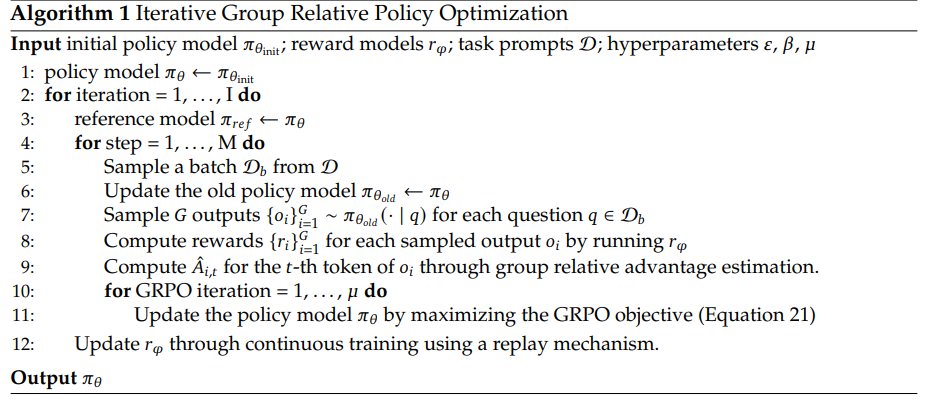

算数モデルで処理できるcontext size は30

### Code

In [ ]:
# @title generate_ids
def generate_ids(input_ids):

    # input_ids = tokenizer.encode(prompt).to(device)
    old_model.eval()

    with torch.no_grad():
        generated_ids = old_model.generate_ids(
            input_ids,
            max_new_tokens=20,
            temperature=0.7,
            top_k=top_k,
            eos_token_id=tokenizer.eos_token_id,
            causal_mask=None,
            max_cache_size=None,
            delay=0.0
            )

    generated_text = tokenizer.decode(generated_ids, use_eos=True)

    return generated_ids

In [ ]:
# test
prompt="1たす2は？<think>1+2=3</think><answer>3</answer>"
target = '<think>' + prompt.split('<think>')[1]
target


In [ ]:
# @title compute_reward
def compute_reward(response, target):
    """
    response: モデルの生成した全文 (e.g. "<think>12+2222</think><answer>35</answer>")
    target: 正解のテキスト (e.g. "<think>12+23=35</think><answer>35</answer>")
    """

    # 報酬の計算
    reward = 0.0

    # 正規表現でthinkタグとanswerタグの内容を抽出
    try:
        pred_equation = re.search(r'<think>(.*?)</think>', response).group(1).replace(' ','')
    except:
        pred_equation = ''
    try:
        pred_answer = re.search(r'<answer>(.*?)</answer>', response).group(1).replace(' ','')
    except:
        pred_answer = ''

    # 正解の数式と答えを抽出
    gt_equation = re.search(r'<think>(.*?)</think>', target).group(1).replace(' ','')
    gt_answer = re.search(r'<answer>(.*?)</answer>', target).group(1).replace(' ','')

    # debug
    # print('pred_equation', pred_equation)
    # print('gt_equation', gt_equation)
    # print()
    # print('pred_answer', pred_answer)
    # print('gt_answer', gt_answer)
    # print('-'*30)

    # 推論（<think>）が完全一致
    if pred_equation == gt_equation:
        reward += 0.5
    elif 0:
        # 推論が一致しないが、式の左辺（=の左側）が一致している場合、報酬0.25
        pred_lhs = pred_equation.split('=')[0].strip()
        gt_lhs = gt_equation.split('=')[0].strip()
        if pred_lhs == gt_lhs:
            reward += 0.25

    # 解答（<answer>）が一致
    if pred_answer == gt_answer:
        reward += 0.5

    # Sample reward
    # reward = torch.FloatTensor([0.5])

    return torch.FloatTensor([reward])

prompt='1たす1は？<think>1+1=20</think><answer>20</answer>'
target='<think>1+1=2</think><answer>2</answer>'
compute_reward(prompt, target)

In [ ]:
#@title compute_advantage
def compute_advantage(group_rewards):
    mean = group_rewards.mean()
    std = group_rewards.std(unbiased=False) + 1e-8
    advantages = (group_rewards - mean) / std
    return advantages

In [ ]:
# test
r = 1.0
r =  torch.tensor([[r],
        [r],
        [0.5],
        [r]])
compute_advantage(r)

In [ ]:
# @title compute_log_probs
def compute_log_probs(model, full_input_ids, grad=False):
    if grad:
        model.train()
        model.reset_kv_cache()
        log_probs = model.compute_log_prob(full_input_ids)
    else:
        model.eval()
        with torch.no_grad():
            log_probs = model.compute_log_prob(full_input_ids)

    return log_probs

In [ ]:
# @title compute_KLD
def compute_KLD(policy_log_probs, ref_log_probs):
    """
    式(2)のKLダイバージェンス計算
    数値的に安定で、効率的で、正確
    """
    ratio = ref_log_probs - policy_log_probs # π_ref / π_θ
    return torch.exp(ratio) - ratio - 1  # exp(x) - x - 1  # 式(2)

def compute_paper_KLD(policy_log_probs, ref_log_probs):
    """
    確率に変換してから計算（アンダーフロー/オーバーフローのリスクが高い）
    指数関数2回、除算、log、epsilon追加
    ゼロ除算防止のepsilonが必要
    """
    # log probabilityから probabilityに変換
    policy_probs = torch.exp(policy_log_probs)
    reference_probs = torch.exp(ref_log_probs)

    # π_ref / π_θ の比率
    ratio = reference_probs / (policy_probs + 1e-8)

    # KL divergence: π_ref/π_θ - log(π_ref/π_θ) - 1
    kl_div = ratio - torch.log(ratio + 1e-8) - 1.0

    return kl_div

In [ ]:
# @title ハイパーパラメータ
# ========================================
# GRPO強化学習 - 推奨設定
# モデル: 小規模 (0.78M params)
# タスク: 四則演算
# ========================================

learning_rate = 1e-5              # SFTの1/2～1/4
# learning_rate = 1e-7            # SFTの1/10
group_size = 4                    # 標準的なサイズ
epsilon = 0.2                      # 標準的なPPOクリップ範囲

beta = 0.1                       # DeepSeek-V2の標準値 小さなKL正則化
# beta = 2.0
num_iterations = 5000            # 十分な学習回数
num_steps_per_iteration = 5     # 標準 50
top_k = 5                         # 適度な多様性
temperature = 1.0                 # 標準
batch_size = 16                   # GRPO標準
seq_len=20
seed = 2                         # 再現性
gradient_clip_norm = 1.0          # 勾配クリッピング (一般形)
# gradient_clip_norm = 0.01       # debug


In [ ]:
#@title インスタンス化　強化学習用のラッパーモデル

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# 事前学習モデルをインスタンス化
policy_base_model = DeepSeekCode(args, device)
old_base_model = DeepSeekCode(args, device)
ref_base_model = DeepSeekCode(args, device)

# 強化学習用ラッパーの作成
# フルモデル
policy_model = DeepSeekFullModel(policy_base_model).to(device)
old_model = DeepSeekFullModel(old_base_model).to(device)
ref_model = DeepSeekFullModel(ref_base_model).to(device)

# # LoRAを適用
# policy_model = DeepSeekLoRA(policy_base_model,lora_rank=lora_rank, lora_alpha=lora_alpha).to(device)
# old_model = DeepSeekLoRA(old_base_model,lora_rank=lora_rank, lora_alpha=lora_alpha).to(device)
# ref_model = DeepSeekLoRA(ref_base_model,lora_rank=lora_rank, lora_alpha=lora_alpha).to(device)

# SFTチェックポイントからロード
load_checkpoint(args, policy_model, SFT_checkpoint_path, SFT_optimizer)
load_checkpoint(args, old_model, SFT_checkpoint_path)
load_checkpoint(args, ref_model, SFT_checkpoint_path)

# GRPOでのold/refモデル固定（勾配を無効化）
for param in old_model.parameters():
    param.requires_grad = False
for param in ref_model.parameters():
    param.requires_grad = False

# オプティマイザの設定 (学習可能なパラメータのみ渡す)
grpo_optimizer = AdamW(
                    policy_model.parameters(), # 重み減衰付きAdam
                    lr=learning_rate,
                    betas=(0.9, 0.95),
                    weight_decay=0.1,  # L2正則化
                    eps=1e-8  # 0 除算回避のための定数
)

In [ ]:
# debug
old_model.load_state_dict(policy_model.state_dict())

In [ ]:
# debug
for i in range(1):
    input_tokens_list, target_tokens_list = make_dataset(create_arithmetic_samples(tokenizer, 32))

    for i in range(16):
        input_tokens = input_tokens_list[i]
        input_ids = tokenizer.encode(input_tokens).to(device) # torch.Size([S])
        o = old_model.generate_ids(input_ids, max_new_tokens=20)
        print(o)

In [ ]:
# @title GRPOの実行（バッチ版：grpo2 完成版）
#
# grpo1 を以下の点で拡張：
#   - 1イテレーションで複数質問（バッチ）をロールアウト収集 → まとめて学習
#   - サンプリングは old_model から行う（PPO標準）
#   - Advantage は「質問（グループ）ごと」に正規化（GRPOの本質）
#
# 注意：質問ごとにプロンプト長 S が異なるため、grpo1 のように全体を
# 1本の (ΣG, L) に flatten できない。よってグループ構造を保持し、
# グループ単位で更新する（グループ内は S 固定・生成長 T=20 固定）。

# ===== ハイパーパラメータ =====
# （config 側の group_size / batch_size を使う場合は置き換えてください）
num_questions_per_iteration = 32   # 1イテレーションあたりの質問数（バッチ）
group_size = 16                    # 1質問あたりのサンプル数 G
num_ppo_epochs = 1                 # 収集データを何回更新に回すか（μ）

for iteration in range(num_iterations):
    print("\n Iteration:", iteration + 1)

    # ========================================
    # old_model を現在の policy で更新（PPO標準パターン）
    #   → このイテレーション中、old_model / ref_model は固定
    # ========================================
    old_model.load_state_dict(policy_model.state_dict())

    # ========================================
    # Phase 1: ロールアウト収集（勾配なし）
    # ========================================
    input_tokens_list, target_tokens_list = make_dataset(
        create_arithmetic_samples(tokenizer, num_questions_per_iteration))

    rollouts = []  # 質問（グループ）ごとに 1 レコード収集

    for input_tokens, target_tokens in zip(input_tokens_list, target_tokens_list):
        print('input_tokens',input_tokens)
        input_ids = tokenizer.encode(input_tokens).to(device)  # [S]

        outputs = []
        rewards = []

        # グループサイズ分のサンプルを old_model から生成
        for i in range(group_size):
            generated_ids = old_model.generate_ids(input_ids, max_new_tokens=20, temperature=0.7, top_k=5)  # [1, T]
            outputs.append(generated_ids)

            generated_text = tokenizer.decode(generated_ids)
            print('generated_text',generated_text)
            reward = compute_reward(generated_text, target_tokens)  # [1]
            rewards.append(reward)

        # --- グループが揃ってからまとめる（ここがバグ修正ポイント）---
        outputs = torch.cat(outputs, dim=0)              # [G, T]
        rewards = torch.cat(rewards, dim=0).to(device)   # [G]

        print('rewards', rewards)

        # Advantage 計算（DeepSeek論文 Equation 34/28/3）: グループ単位で正規化
        advantages = compute_advantage(rewards)          # [G]

        rollouts.append({
            "input_ids":  input_ids.view(-1),  # [S]   プロンプト（更新フェーズで必要）
            "outputs":    outputs,             # [G, T]
            "advantages": advantages,          # [G]
        })

    # ========================================
    # Phase 2: ポリシー更新（勾配あり）
    #   グループ（質問）ごとに 1 ステップ更新（grpo1 と同じ数式）
    # ========================================
    for _ in range(num_ppo_epochs):
        for rec in rollouts:
            input_ids     = rec["input_ids"]   # [S]
            generated_ids = rec["outputs"]     # [G, T]
            advantages    = rec["advantages"]  # [G]

            input_seqlen = input_ids.size(-1)
            G, T = generated_ids.shape

            # ----- 入力(プロンプト) + 生成 を結合して [G, S+T] に -----
            prompt = input_ids.unsqueeze(0).expand(G, -1)            # [G, S]
            full_input_ids = torch.cat([prompt, generated_ids], 1)  # [G, S+T]

            # ----- 各モデルのログ確率分布（grpo1 と同じ）-----
            policy_log_probs = compute_log_probs(policy_model, full_input_ids, grad=True)
            old_log_probs    = compute_log_probs(old_model, full_input_ids)
            ref_log_probs    = compute_log_probs(ref_model, full_input_ids)

            # ----- 入力トークン部分を除去（grpo1 と同じスライス規約）-----
            policy_log_probs = policy_log_probs[:, input_seqlen:, :]  # [G, T, V]
            old_log_probs    = old_log_probs[:, input_seqlen:, :]
            ref_log_probs    = ref_log_probs[:, input_seqlen:, :]

            # ----- 生成トークンに対応するログ確率を抽出 -----
            idx = generated_ids.unsqueeze(-1)  # [G, T, 1]
            policy_log_probs = torch.gather(policy_log_probs, 2, idx).squeeze(-1)  # [G, T]
            old_log_probs    = torch.gather(old_log_probs, 2, idx).squeeze(-1)
            ref_log_probs    = torch.gather(ref_log_probs, 2, idx).squeeze(-1)

            # ----- PPO ratio とクリップ（Equation 32/26/1）-----
            ratio = torch.exp(policy_log_probs - old_log_probs)
            clipped_ratio = torch.clamp(ratio, 1.0 - epsilon, 1.0 + epsilon)

            # ----- Advantage をトークンレベルに拡張（Outcome Supervision）-----
            adv = advantages.unsqueeze(-1).expand(G, T)  # [G, T]

            # ----- Surrogate Loss（Equation 32/26/1）-----
            surrogate_loss = -torch.min(ratio * adv, clipped_ratio * adv).mean()

            # ----- KL Divergence（Equation 33/27/2、ref は固定SFTモデル）-----
            kld = compute_KLD(policy_log_probs, ref_log_probs)
            kl_loss = beta * kld.mean()

            # ----- 最終的なGRPO損失 -----
            loss = surrogate_loss + kl_loss

            # ----- 逆伝播と最適化 -----
            grpo_optimizer.zero_grad()
            loss.backward()
            if gradient_clip_norm > 0:
                torch.nn.utils.clip_grad_norm_(
                    policy_model.parameters(),
                    max_norm=gradient_clip_norm
                )
            grpo_optimizer.step()

    # ログ（最後のグループの統計を表示）
    print(f"    Total Loss: {loss.item():.6f}")
    print(f"    Surrogate:  {surrogate_loss.item():.6f}")
    print(f"    KL Loss:    {kl_loss.item():.6f}")
    print(f"    Advantages: {advantages.tolist()}")
    print(f"    Ratio: mean={ratio.mean().item():.4f}, "
          f"std={ratio.std().item():.4f}, "
          f"min={ratio.min().item():.4f}, "
          f"max={ratio.max().item():.4f}")
    print(f"    KL div: {kld.mean().item():.6f}")

    # ========================================
    # 評価（任意）
    # ========================================
    policy_model.eval()
    with torch.no_grad():
        gen = policy_model.generate_ids(rollouts[-1]["input_ids"])
        gen_text = tokenizer.decode(gen, use_eos=True)

    print('[Supervised data]')
    print(f"  Input:  {input_tokens_list[-1]}")
    print(f"  Output: {gen_text}")

    print('[Test data]')
    test(policy_model)

    policy_model.train()

print("\n" + "="*70)
print("GRPO training completed!")
print("="*70)

符号付きオペランド (operand)は200通り、演算子が4通り、答えも200通り<br>
200 x 200 x 200 x 4 = 4000000 通り

In [ ]:
# test
test(policy_model,prompt='20ひく2は')
test(policy_model,prompt='20たす2は')
test(policy_model,prompt='21/3=')
test(policy_model,prompt='-2ー64は')
test(policy_model,prompt='-10×4は')

In [ ]:
# test
test(policy_model)

In [ ]:
test(policy_model, prompt='72-25=')